<a href="https://colab.research.google.com/github/Uwimpaye-yve/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import joblib

# 1. Save the Scaler
joblib.dump(scaler, 'scaler.pkl')

# 2. Save the Model (This is the 'brain')
# Replace 'rf_model' with whatever you named your best performing model
joblib.dump(rf_model, 'best_life_expectancy_model.pkl')

print("Files generated successfully!")

Files generated successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv('Life Expectancy Data.csv')
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [3]:
# Identify numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill missing values only for numeric columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Handle the status column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

# Fill missing values for categorical if any

print("Data cleaned successfully!")

Data cleaned successfully!


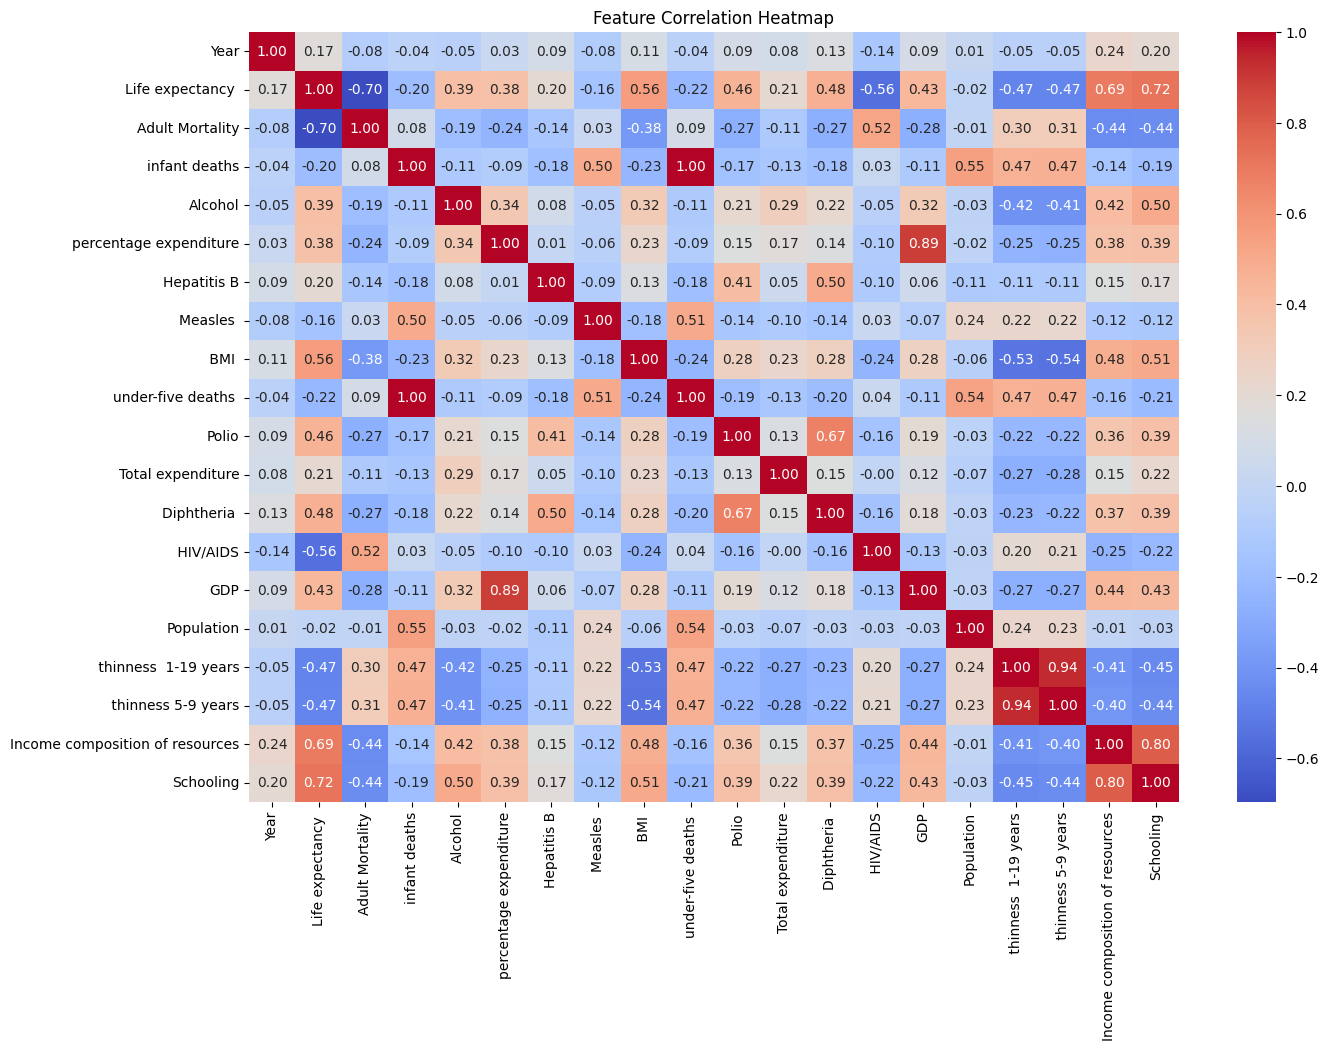

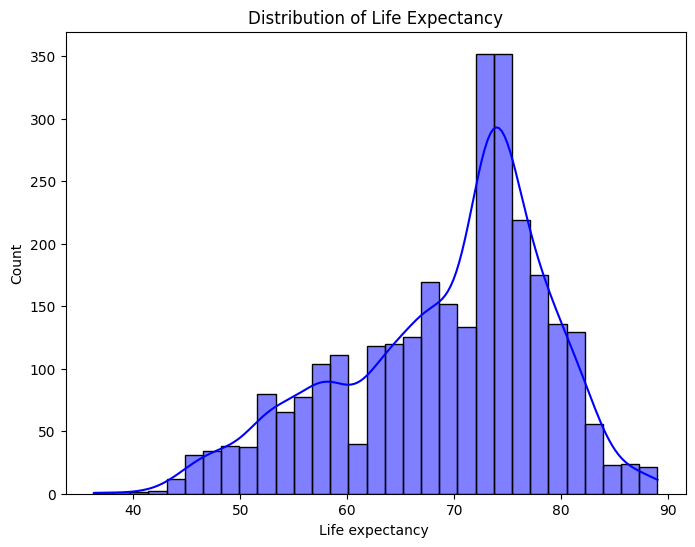

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap to show correlations
plt.figure(figsize=(15, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(df['Life expectancy '], kde=True, color='blue')
plt.title('Distribution of Life Expectancy')
plt.show()

In [5]:
# Drop 'Country' and the target 'Life expectancy '
X = df.drop(['Life expectancy ', 'Country'], axis=1)
y = df['Life expectancy ']

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 1. Linear Regression
lr_model = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01)
lr_model.fit(X_train_scaled, y_train)

# 2. Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 3. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [7]:
models = {'Linear Regression': lr_model, 'Decision Tree': dt_model, 'Random Forest': rf_model}
results = {}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = rmse
    print(f"{name} RMSE: {rmse:.4f}")

# Find and save the best model
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]

import joblib
joblib.dump(best_model, 'best_life_expectancy_model.pkl')
print(f"\nSaved the best model: {best_model_name}")

Linear Regression RMSE: 4.0201
Decision Tree RMSE: 2.4958
Random Forest RMSE: 1.6479

Saved the best model: Random Forest


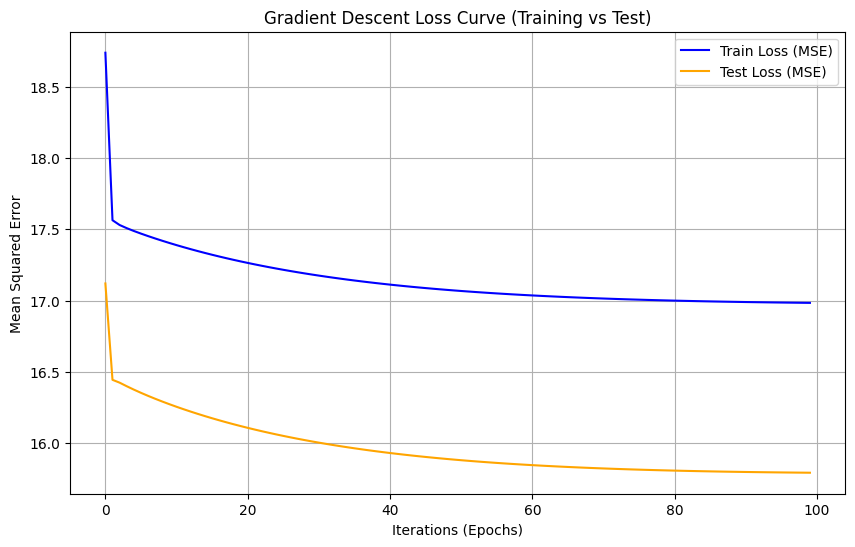

In [8]:
# Create a model for the loss curve analysis
sgd_curve = SGDRegressor(max_iter=1, tol=None, eta0=0.01, warm_start=True, penalty=None, random_state=42)

train_losses = []
test_losses = []

# Simulate 100 iterations of Gradient Descent
for i in range(100):
    sgd_curve.fit(X_train_scaled, y_train)
    # Calculate Mean Squared Error for both sets
    train_losses.append(mean_squared_error(y_train, sgd_curve.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd_curve.predict(X_test_scaled)))

# Plotting the Loss Curve as required by the rubric
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)', color='blue')
plt.plot(test_losses, label='Test Loss (MSE)', color='orange')
plt.title('Gradient Descent Loss Curve (Training vs Test)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

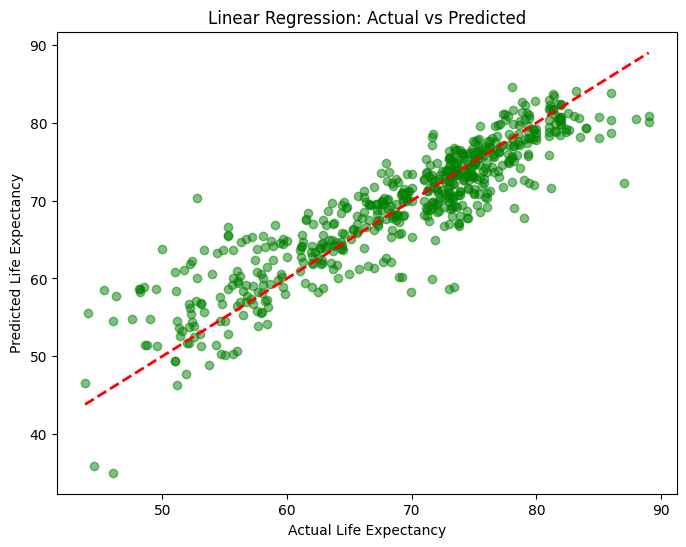

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_model.predict(X_test_scaled), alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()